In [3]:
import paho.mqtt.client as mqtt
import json
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import lfilter, find_peaks
import pywt
import onnxruntime as ort

l_aux = []
Fs = 500
##Funciones para el preprocesamiento y procesamiento de la señal
def pan_tompkins(signal, Fs):
    b_der = np.array([-1, -2, 0, 2, 1])
    b_der = (1/8) * b_der
    fder_signal = lfilter(b_der, 1, signal)
    f_sq_signal = np.square(fder_signal)
    N_mov_win = 75
    b_mov_win = np.ones(N_mov_win) / N_mov_win
    f_mov_win_in_signal = lfilter(b_mov_win, 1, f_sq_signal)
    peaks, _ = find_peaks(f_mov_win_in_signal, distance=100)
    samples = len(peaks)
    th_I1 = np.max(f_mov_win_in_signal[peaks[:samples]]) * 0.25
    th_I2 = 0.5 * np.mean(f_mov_win_in_signal[peaks[:samples]])
    end_qrs = f_mov_win_in_signal > th_I1
    roll_qrs_r = np.roll(end_qrs, 1)
    roll_qrs_l = np.roll(end_qrs, -1)
    end_qrs = np.logical_xor(end_qrs, roll_qrs_r)
    end_qrs = np.logical_and(end_qrs, roll_qrs_l)
    start_qrs = f_mov_win_in_signal < th_I2
    roll_qrs_l = np.roll(start_qrs, -1)
    roll_qrs_r = np.roll(start_qrs, 1)
    start_qrs = np.logical_xor(start_qrs, roll_qrs_l)
    start_qrs = np.logical_and(start_qrs, roll_qrs_r)
    QRS = np.logical_or(start_qrs, end_qrs)
    return fder_signal, f_sq_signal, f_mov_win_in_signal, peaks, QRS

def validate_peaks(signal, peaks, min_distance=100, threshold_factor=0.6):
    validated_peaks = []
    if len(peaks) == 0:
        return validated_peaks
    max_value = np.max(signal)
    threshold = threshold_factor * max_value
    for i in range(len(peaks)):
        if signal[peaks[i]] > threshold:
            if len(validated_peaks) == 0 or (peaks[i] - validated_peaks[-1]) > min_distance:
                validated_peaks.append(peaks[i])
    return validated_peaks

samples_before_peak = 100
samples_after_peak = 150

def extract_beats(signal, peaks, samples_before_peak, samples_after_peak):
    beats = []
    for peak in peaks:
        start = peak - samples_before_peak
        end = peak + samples_after_peak
        if start >= 0 and end < len(signal):
            beat = signal[start:end]
            beats.append(beat)
    return beats

def extract_wavelet_features(beats, wavelet='db4', level=1):
    features = []
    for beat in beats:
        coeffs = pywt.wavedec(beat, wavelet, level=level)
        print("coeffs:",coeffs)
        feature = np.concatenate([coeff for coeff in coeffs])
        features.append(feature)
    return np.array(features)

def predict_with_onnx(features, model_path='C:/Users/Alessandra/Downloads/Instrumentacion_Proyecto/rf_model.onnx'):
    ort_session = ort.InferenceSession(model_path)
    features = features.astype(np.float32)
    inputs = {ort_session.get_inputs()[0].name: features}
    predictions = ort_session.run(None, inputs)
    print("predicciones:",predictions)
    return predictions

def process_signal_in_real_time(signal, Fs):
    print("signal:", signal)
    fder_signal, f_sq_signal, f_mov_win_in_signal, peaks, QRS = pan_tompkins(signal, Fs)
    validated_peaks = validate_peaks(f_mov_win_in_signal, peaks)
    beats = extract_beats(signal, validated_peaks, samples_before_peak, samples_after_peak)
    #print("beats:",beats)
    features = extract_wavelet_features(beats)
    predictions = predict_with_onnx(features)
    return predictions


# The callback for when the client receives a CONNACK response from the server.
def on_connect(client, userdata, flags, reason_code, properties):
    #print(f"Connected with result code {reason_code}")
    client.subscribe("/curso/instrumentacion/data")


/curso/instrumentacion/data b"{'data': 1.97, 'n': 0}"
/curso/instrumentacion/data b"{'data': 1.98, 'n': 1}"
/curso/instrumentacion/data b"{'data': 1.99, 'n': 2}"
/curso/instrumentacion/data b"{'data': 2.01, 'n': 3}"
/curso/instrumentacion/data b"{'data': 2.06, 'n': 4}"
/curso/instrumentacion/data b"{'data': 2.08, 'n': 5}"
/curso/instrumentacion/data b"{'data': 2.07, 'n': 6}"
/curso/instrumentacion/data b"{'data': 1.98, 'n': 7}"
/curso/instrumentacion/data b"{'data': 1.97, 'n': 8}"
/curso/instrumentacion/data b"{'data': 1.90, 'n': 9}"
/curso/instrumentacion/data b"{'data': 1.81, 'n': 10}"
/curso/instrumentacion/data b"{'data': 1.74, 'n': 11}"
/curso/instrumentacion/data b"{'data': 1.70, 'n': 12}"
/curso/instrumentacion/data b"{'data': 1.69, 'n': 13}"
/curso/instrumentacion/data b"{'data': 1.70, 'n': 14}"
/curso/instrumentacion/data b"{'data': 1.70, 'n': 15}"
/curso/instrumentacion/data b"{'data': 1.70, 'n': 16}"
/curso/instrumentacion/data b"{'data': 1.71, 'n': 17}"
/curso/instrumentaci

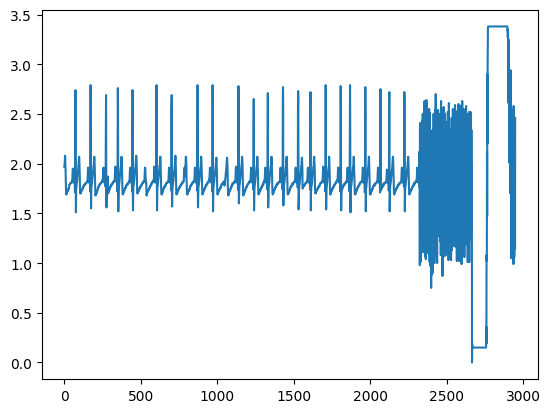

KeyboardInterrupt: 

In [4]:
# The callback for when a PUBLISH message is received from the server.
def on_message(client, userdata, msg):
    global l_aux, mqttc

    print(msg.topic + " " + str(msg.payload))
    data_aux = msg.payload.decode(encoding='UTF-8')
    y = eval(json.loads(json.dumps(data_aux)))
    #print("y:::", y)
    data = y["data"]
    n = y["n"]
    #if n != 1999:
    if n != 2947:
        l_aux.append(data)
    else:
        # Disconnect from MQTT broker before plotting
        mqttc.disconnect()
        signal = np.array(l_aux)
        predictions = process_signal_in_real_time(signal, Fs)
        for i, prediction in enumerate(predictions[0]):
            payload = json.dumps({'prediction': int(prediction), 'beat': i})
            mqttc.publish("/curso/instrumentacion/processed_data", payload)
        plt.plot(l_aux)
        plt.show(block=True)
        plt.pause(15)
        l_aux = []
        # Reconnect to MQTT broker after plotting
        mqttc.connect("test.mosquitto.org", 1883, 60)

mqttc = mqtt.Client(mqtt.CallbackAPIVersion.VERSION2)
mqttc.on_connect = on_connect
mqttc.on_message = on_message

mqttc.connect("test.mosquitto.org", 1883, 60)
mqttc.loop_forever()